# 🧩 Customer Segmentation with K-Means Clustering

## 1. Problem Definition — *What are we trying to solve?*

**Customer Segmentation** is the practice of dividing a customer base into groups of individuals that are similar in specific ways — such as age, income, spending habits, or geographic location. It's one of the most widely used unsupervised learning techniques in marketing.

### 🎯 Business Goal
> *"Know your customer, and your customer will love you."* — A retail business wants to understand its customer base so it can:
- ✅ Target marketing campaigns more effectively
- ✅ Personalise product recommendations
- ✅ Identify high-value customer segments
- ✅ Reduce churn by understanding what each segment needs

### 📊 The Data
We have **400 customers** with these attributes:
- `CustomerID` — Unique identifier (won't be used for modelling)
- `Gender` — Male / Female
- `Age` — Customer's age in years (numeric)
- `AnnualIncome_k` — Annual income in thousands of \$ (numeric)
- `SpendingScore` — A score (1–100) assigned by the mall based on customer behaviour and spending nature (numeric)

### 🔬 Our Approach (Roadmap)

| Step | What We Do | Why It Matters |
|:----:|:-----------|:---------------|
| 1 | **Load & Explore Data** | Know your data — shapes, types, missing values |
| 2 | **Exploratory Data Analysis** | Visualise distributions and relationships |
| 3 | **Preprocessing** | Scale features so K-Means works correctly |
| 4 | **Find Optimal K** | Elbow method + Silhouette analysis |
| 5 | **Apply K-Means** | Cluster the customers |
| 6 | **PCA for Visualisation** | Reduce dimensions to see clusters in 2D |
| 7 | **Profile the Segments** | Describe what each cluster *means* |
| 8 | **Business Recommendations** | Turn data into action |



In [1]:
# ⚙️ Cell 2 — Import libraries
# We'll use pandas for data, numpy for numbers, matplotlib/seaborn for plots,
# and scikit-learn for clustering + preprocessing.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Plot styling for a professional look
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('✅ All libraries imported successfully')
print(f'   pandas v{pd.__version__}')
print(f'   numpy v{np.__version__}')
print(f'   sklearn v{__import__("sklearn").__version__}')


✅ All libraries imported successfully
   pandas v3.0.2
   numpy v2.4.4
   sklearn v1.8.0


## 2. Data Loading — *Getting our hands on the data*

We load the CSV into a pandas DataFrame. This is the first step in every data science project — bring the data into memory so we can inspect, clean, and analyse it.

> 💡 **Why CSV?** CSV (Comma-Separated Values) is the most universal format for tabular data. Almost every tool can read it.


In [2]:
# Load the dataset
import os

possible_paths = [
    'data/customer_data.csv',
    '../data/customer_data.csv',
]

df_path = next((p for p in possible_paths if os.path.exists(p)), None)
if df_path is None:
    raise FileNotFoundError('customer_data.csv not found. Run data/generate_data.py first.')

df = pd.read_csv(df_path)
print(f'Loaded: {df_path}')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')


Loaded: ../data/customer_data.csv
Shape: 400 rows x 5 columns


## 3. Initial Data Exploration — *Can we trust the data?*

Before any modelling, we need to understand the data we're working with. This phase answers:
- ✅ What **types** of data do we have? (numeric, categorical)
- ✅ Are there **missing values**?
- ✅ What's the **range** and **distribution** of each feature?
- ✅ Are there **duplicates** or obvious data quality issues?

> 📐 **Central Tendency intuition**: `mean` ≈ average, `median` (50%) = middle value. If mean and median are far apart, the distribution is skewed.


In [3]:
# 🔍 Cell 4 — Peek at the data
print('─── First 5 rows ───')
display(df.head())

print('\n─── Data types & non-null counts ───')
display(df.info())

print('\n─── Summary statistics ───')
display(df.describe().round(2))

print('\n─── Missing values check ───')
print(df.isnull().sum().to_string())

print('\n─── Gender distribution ───')
print(df['Gender'].value_counts().to_string())


─── First 5 rows ───


,CustomerID,Gender,Age,AnnualIncome_k,SpendingScore
0,1,Male,24,15.8,78
1,2,Male,21,25.8,79
2,3,Female,25,26.6,84
3,4,Female,30,22.0,83
4,5,Female,21,28.4,64



─── Data types & non-null counts ───
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      400 non-null    int64  
 1   Gender          400 non-null    str    
 2   Age             400 non-null    int64  
 3   AnnualIncome_k  400 non-null    float64
 4   SpendingScore   400 non-null    int64  
dtypes: float64(1), int64(3), str(1)
memory usage: 15.8 KB


None


─── Summary statistics ───


,CustomerID,Age,AnnualIncome_k,SpendingScore
count,400.00,400.00,400.00,400.00
mean,200.50,41.18,52.79,59.27
std,115.61,14.45,19.90,22.62
min,1.00,18.00,10.80,9.00
25%,100.75,30.00,37.88,39.75
50%,200.50,41.00,51.70,62.50
75%,300.25,52.25,66.72,79.00
max,400.00,73.00,110.80,100.00



─── Missing values check ───
CustomerID        0
Gender            0
Age               0
AnnualIncome_k    0
SpendingScore     0

─── Gender distribution ───
Gender
Female    216
Male      184


## 4. Exploratory Data Analysis (EDA) — *Let the data speak*

EDA is where we build intuition. We visualise each feature to understand its shape, spot outliers, and discover patterns that will guide our modelling.

### 📊 Univariate Analysis (one variable at a time)

**Histograms** show the distribution of a single numeric feature. The shape tells us:
- **Left-skewed** (tail on left) → most values are high
- **Right-skewed** (tail on right) → most values are low
- **Bimodal** (two peaks) → there might be natural groups in the data!

> 🙋 **Why does distribution shape matter for clustering?**
> If a feature is heavily skewed, K-Means may form clusters around dense regions rather than meaningful groups. StandardScaler helps but can't fix fundamental shape issues.


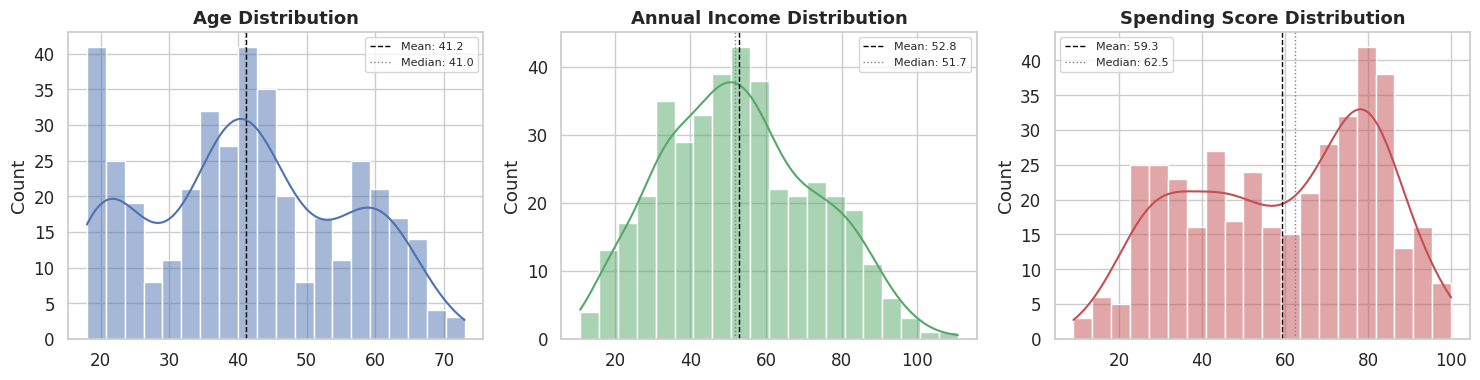

📈 Distribution plots saved to visualization/distributions.png


In [4]:
# 📊 Cell 5 — Univariate: Feature distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

features_to_plot = ['Age', 'AnnualIncome_k', 'SpendingScore']
titles = ['Age Distribution', 'Annual Income Distribution', 'Spending Score Distribution']
colors = ['#4C72B0', '#55A868', '#C44E52']

for ax, col, title, color in zip(axes, features_to_plot, titles, colors):
    sns.histplot(df[col], kde=True, bins=20, color=color, ax=ax, edgecolor='white')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1, label=f'Mean: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='gray', linestyle=':', linewidth=1, label=f'Median: {df[col].median():.1f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../visualization/distributions.png', dpi=100, bbox_inches='tight')
plt.show()

print('📈 Distribution plots saved to visualization/distributions.png')


### 👤 Gender Breakdown
Let's check whether the dataset is balanced by gender. An imbalanced split won't break clustering, but it's good to know.


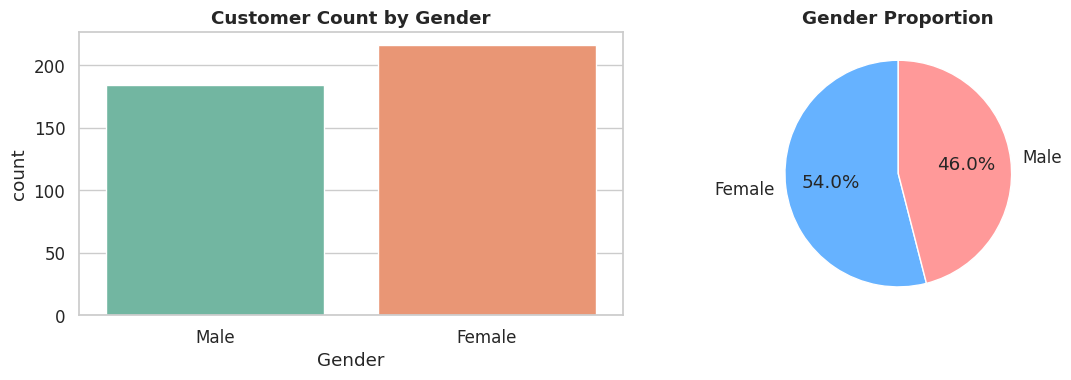

👥 Male: 184  |  Female: 216


In [5]:
# 👤 Cell 6 — Gender analysis
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(data=df, x='Gender', hue='Gender', palette='Set2', ax=axes[0], legend=False)
axes[0].set_title('Customer Count by Gender', fontweight='bold')

# Pie chart
gender_counts = df['Gender'].value_counts()
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
            startangle=90, colors=['#66B2FF', '#FF9999'], wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Gender Proportion', fontweight='bold')

plt.tight_layout()
plt.savefig('../visualization/gender_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'👥 Male: {gender_counts.get("Male", 0)}  |  Female: {gender_counts.get("Female", 0)}')


### 🔗 Bivariate Analysis (two variables at once)

**Scatter plots** show how two numeric features relate. If we see **clumps** or **clusters** in the scatter, that's a strong signal that K-Means will find meaningful groups.

**Pairplots** extend this to all numeric features simultaneously — the diagonal shows distributions, the off-diagonals show pairwise relationships.

> 💡 **Key insight**: The relationship between `AnnualIncome_k` and `SpendingScore` is *especially* important. In retail, these two dimensions often define the most actionable segments (e.g., high-income high-spenders vs. low-income high-spenders).


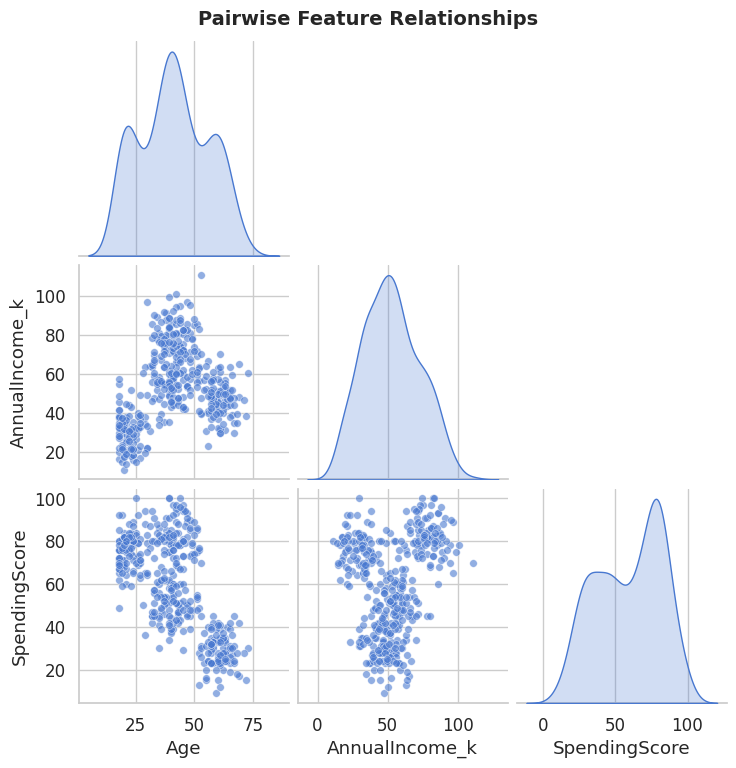

In [6]:
# 🔗 Cell 7 — Pairwise relationships
# Numeric features only (exclude CustomerID since it's an arbitrary ID)
numeric_cols = ['Age', 'AnnualIncome_k', 'SpendingScore']

sns.pairplot(df[numeric_cols], diag_kind='kde', corner=True, plot_kws={'alpha': 0.6, 's': 30})
plt.suptitle('Pairwise Feature Relationships', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('../visualization/pairplot.png', dpi=100, bbox_inches='tight')
plt.show()


### 📈 Correlation Heatmap

Correlation measures **linear** relationships between variables:
- **+1**: Perfect positive correlation (both go up together)
- **0**: No linear relationship
- **-1**: Perfect negative correlation (one goes up, the other goes down)

> ⚠️ **Warning for clustering**: K-Means can be sensitive to highly correlated features because it treats each dimension equally. High correlation means redundant information — PCA (later) can help.


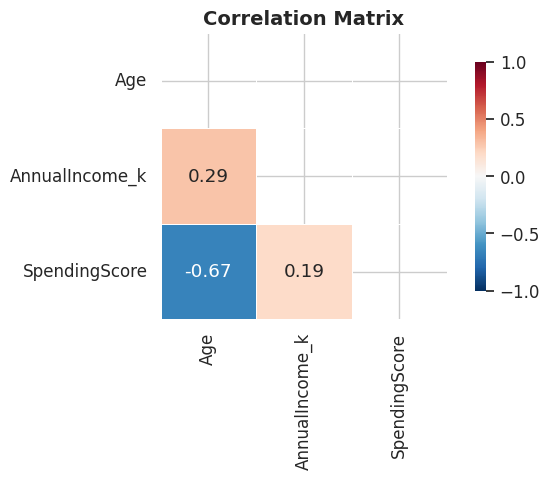

📊 Interesting observations:
   • Age vs AnnualIncome_k: r² = 0.285 (weak positive)
   • Age vs SpendingScore: r² = -0.666 (strong negative)
   • AnnualIncome_k vs SpendingScore: r² = 0.193 (weak positive)


In [7]:
# 📈 Cell 8 — Correlation heatmap
plt.figure(figsize=(7, 5))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            mask=mask, vmin=-1, vmax=1)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualization/correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

print('📊 Interesting observations:')
for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        val = corr.iloc[i, j]
        strength = 'strong' if abs(val) > 0.5 else ('moderate' if abs(val) > 0.3 else 'weak')
        direction = 'positive' if val > 0 else 'negative'
        print(f'   • {numeric_cols[i]} vs {numeric_cols[j]}: r² = {val:.3f} ({strength} {direction})')


## 5. Data Preprocessing — *Preparing data for K-Means*

### Why can't we feed raw data into K-Means?

K-Means relies on **Euclidean distance** to measure similarity between points. If features have different scales (e.g., Age ranges 18–80, but Income ranges 10–130), the feature with larger numbers dominates the distance calculation.

```
Example: Distance between two customers
  Customer A: Age=25, Income=30k
  Customer B: Age=35, Income=80k
  Raw Euclidean distance ≈ √((25-35)² + (30-80)²) = √(100 + 2500) = 51
  → Income contributes 96% of the distance! Age barely matters.
```

### 🔧 The fix: **StandardScaler**
StandardScaler transforms each feature to have **mean = 0** and **standard deviation = 1** (z-score normalisation):

$$ z = \frac{x - \mu}{\sigma} $$

Now every feature contributes equally to the distance metric.

### What about Gender?
We convert it to a numeric value with **Label Encoding** (Male → 0, Female → 1). For clustering, we could either include it or leave it out — let's try both approaches and see what works better.

> 💡 **Decision**: We'll cluster on the 3 numeric features (Age, Income, Spending) for clarity. After clustering, we'll analyse Gender differences *within* each segment.


In [8]:
# 🧹 Cell 9 — Feature selection & scaling
# Step 1: Select features (CustomerID is an identifier, not a feature)
feature_cols = ['Age', 'AnnualIncome_k', 'SpendingScore']
X = df[feature_cols].copy()

print('Before scaling — first 5 rows:')
display(X.head())

# Step 2: Scale features to zero mean, unit variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print('\nAfter scaling (mean ≈ 0, std ≈ 1) — first 5 rows:')
display(X_scaled_df.head())

# Quick sanity check
print(f'\n✅ Feature means after scaling: {X_scaled_df.mean().round(6).values}')
print(f'✅ Feature stds  after scaling: {X_scaled_df.std().round(6).values}')


Before scaling — first 5 rows:


,Age,AnnualIncome_k,SpendingScore
0,24,15.8,78
1,21,25.8,79
2,25,26.6,84
3,30,22.0,83
4,21,28.4,64



After scaling (mean ≈ 0, std ≈ 1) — first 5 rows:


,Age,AnnualIncome_k,SpendingScore
0,-1.190099,-1.861382,0.829326
1,-1.397946,-1.358116,0.873598
2,-1.120816,-1.317854,1.094958
3,-0.774404,-1.549357,1.050686
4,-1.397946,-1.227266,0.209517



✅ Feature means after scaling: [-0. -0.  0.]
✅ Feature stds  after scaling: [1.001252 1.001252 1.001252]


## 6. Finding the Optimal Number of Clusters (K)

K-Means requires us to specify **K** — the number of clusters — upfront. But how do we choose K?

### 📍 Elbow Method
We run K-Means for K = 1 to 10 and compute **WCSS** (Within-Cluster Sum of Squares, also called **inertia**):

$$ \text{WCSS} = \sum_{i=1}^{K} \sum_{x \in C_i} ||x - \mu_i||^2 $$

WCSS measures how *compact* clusters are — smaller WCSS means tighter clusters. As K increases, WCSS always decreases (more clusters → points are closer to their centroid). We look for the **elbow point** where the rate of decrease slows down — that's the optimal K.

> 🧠 **Intuition**: Think of it like ordering pizza. The first pizza feeds 8 people (big gain). The second feeds 4 more (smaller gain). The third only feeds 2. At some point, ordering another pizza doesn't help much — that's the elbow.


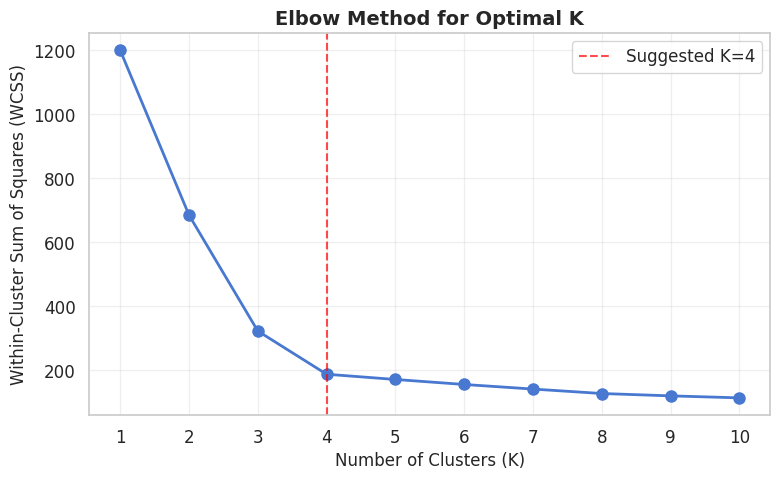

Inertia values:
   K=1:  WCSS = 1200.00
   K=2:  WCSS = 684.75
   K=3:  WCSS = 322.14
   K=4:  WCSS = 187.13  ←  Elbow point!
   K=5:  WCSS = 170.77
   K=6:  WCSS = 155.12
   K=7:  WCSS = 140.76
   K=8:  WCSS = 126.86
   K=9:  WCSS = 119.52
   K=10:  WCSS = 113.23


In [9]:
# 📍 Cell 10 — Elbow Method
inertia_values = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia_values, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Suggested K=4')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
plt.title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.xticks(K_range)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('../visualization/elbow_method.png', dpi=100, bbox_inches='tight')
plt.show()

print('Inertia values:')
for k, inertia in zip(K_range, inertia_values):
    arrow = '  ←  Elbow point!' if k == 4 else ''
    print(f'   K={k}:  WCSS = {inertia:.2f}{arrow}')


### 📐 Silhouette Analysis — *A second opinion*

The elbow method is simple but can be subjective. **Silhouette Score** gives a more objective measure:

For each customer, we compute:
- **a** = mean distance to other points in *its own* cluster (cohesion)
- **b** = mean distance to points in the *nearest neighbour cluster* (separation)

$$ s = \frac{b - a}{\max(a, b)} $$

**Interpretation**:
- **~1**: Point is well-clustered (far from other clusters)
- **~0**: Point is on the boundary between clusters
- **< 0**: Point is probably in the wrong cluster!

We pick the K that maximises the **average silhouette score**.


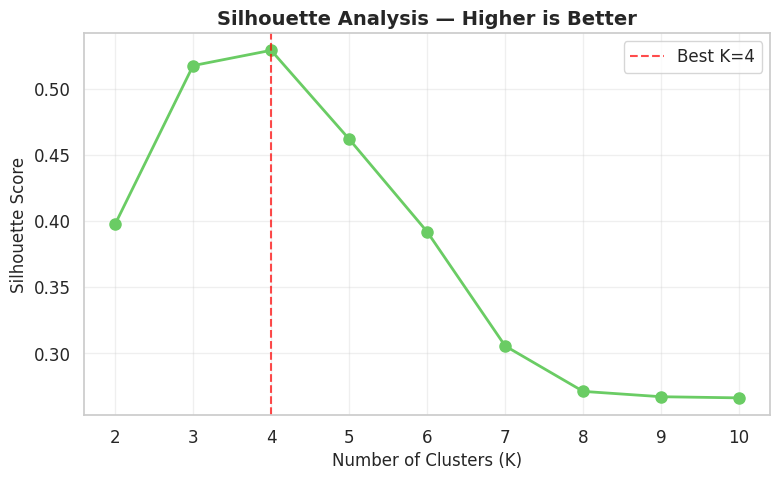

🏆 Best K = 4 (Silhouette Score = 0.5290)
   K=2: Silhouette = 0.3974
   K=3: Silhouette = 0.5174
   K=4: Silhouette = 0.5290 ← Best!
   K=5: Silhouette = 0.4619
   K=6: Silhouette = 0.3918
   K=7: Silhouette = 0.3054
   K=8: Silhouette = 0.2711
   K=9: Silhouette = 0.2670
   K=10: Silhouette = 0.2662


In [10]:
# 📐 Cell 11 — Silhouette Analysis
silhouette_scores = []

for k in range(2, 11):  # silhouette requires at least 2 clusters
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, 'go-', linewidth=2, markersize=8)
best_k = range(2, 11)[silhouette_scores.index(max(silhouette_scores))]
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Best K={best_k}')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Analysis — Higher is Better', fontsize=14, fontweight='bold')
plt.xticks(range(2, 11))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('../visualization/silhouette_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'🏆 Best K = {best_k} (Silhouette Score = {max(silhouette_scores):.4f})')
for k, score in zip(range(2, 11), silhouette_scores):
    mark = ' ← Best!' if k == best_k else ''
    print(f'   K={k}: Silhouette = {score:.4f}{mark}')


## 7. Applying K-Means — *Segmenting the customers*

Now we apply K-Means with our chosen K (from both the elbow and silhouette methods). Each customer gets a **cluster label** from 0 to K-1.

### How K-Means works (intuitively):

1. 🎯 **Initialise** — Randomly pick K points as initial centroids
2. 📌 **Assign** — Each point is assigned to its nearest centroid
3. 📍 **Update** — Recompute centroids as the mean of all points in the cluster
4. 🔁 **Repeat** — Steps 2-3 until centroids stop moving (convergence)

The `n_init=10` parameter runs this process 10 times with different random starts and keeps the best result (lowest inertia). This prevents getting stuck in a bad local minimum.


In [11]:
# 🎯 Cell 12 — Apply K-Means with optimal K
optimal_k = best_k  # from silhouette analysis above
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f'✅ K-Means applied with K = {optimal_k}')
print(f'   Cluster distribution:')
print(df['Cluster'].value_counts().sort_index().to_string())

# Store centroids (in original scale for interpretability)
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
centroid_df = pd.DataFrame(centroids_original, columns=feature_cols)
centroid_df.index.name = 'Cluster'
centroid_df.index = [f'Cluster {i}' for i in range(optimal_k)]

print('\n📍 Cluster centroids (in original units):')
display(centroid_df.round(1))


✅ K-Means applied with K = 4
   Cluster distribution:
Cluster
0    102
1     99
2     99
3    100

📍 Cluster centroids (in original units):


,Age,AnnualIncome_k,SpendingScore
Cluster 0,60.4,47.1,29.3
Cluster 1,22.1,30.0,75.6
Cluster 2,41.8,78.9,82.3
Cluster 3,39.9,55.2,50.9


## 8. Visualising Clusters with PCA

Our data has 3 dimensions (Age, Income, Spending) — we can plot it in 3D, but humans read 2D plots much better. **PCA (Principal Component Analysis)** reduces the 3 dimensions to 2 while preserving as much variance as possible.

### How PCA works (in plain English):

1. Find the direction (principal component) along which the data varies **the most** → PC1
2. Find a *second* direction, perpendicular to PC1, that captures the next most variance → PC2
3. Project the 3D data onto these 2 directions

> 💡 **Interpretation**: If PC1 + PC2 explain > 80% of the variance, our 2D visualisation faithfully represents the data structure. If it's low, we're losing information — but for clustering on 3 features, it's usually excellent.


In [12]:
# 🎨 Cell 13 — PCA for 2D visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'✅ PCA completed: {X_scaled.shape[1]}D → 2D')
print(f'   Explained variance: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}')
print(f'   Total variance preserved: {sum(pca.explained_variance_ratio_):.2%}')

# Component loadings (how much each original feature contributes to each PC)
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=['PC1', 'PC2']
)
print('\n📊 PCA Loadings (contribution of each feature to each component):')
display(loadings.round(3))


✅ PCA completed: 3D → 2D
   Explained variance: PC1=55.78%, PC2=37.83%
   Total variance preserved: 93.61%

📊 PCA Loadings (contribution of each feature to each component):


,PC1,PC2
Age,0.722,0.194
AnnualIncome_k,0.110,0.915
SpendingScore,-0.683,0.353


### 🖼️ 2D Cluster Visualisation

Each color represents a different customer segment. If the clusters are well-separated in the plot, K-Means did a good job!


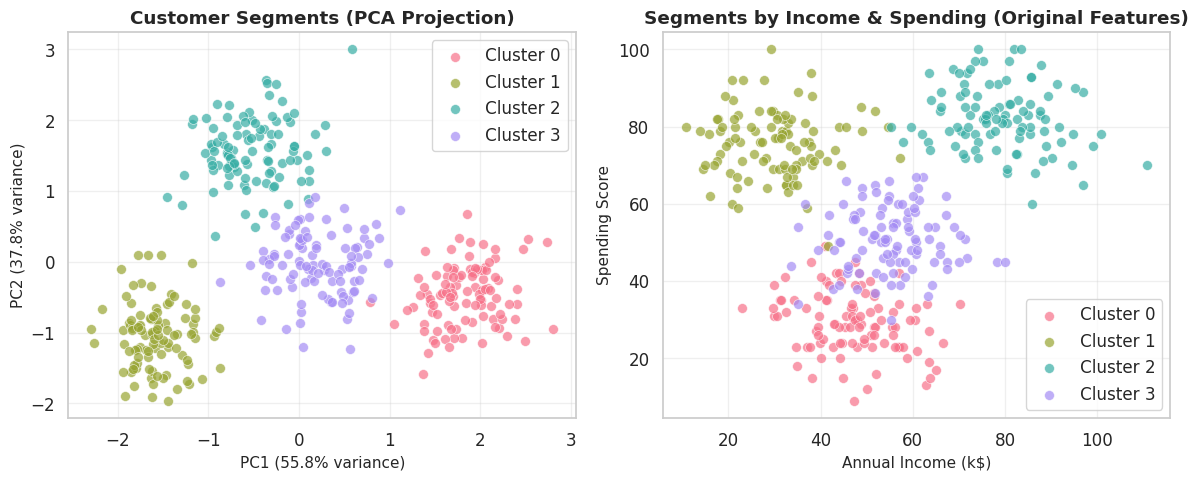

In [13]:
# 🖼️ Cell 14 — Plot clusters in 2D PCA space
plt.figure(figsize=(12, 5))

# Subplot 1: PCA projection
plt.subplot(1, 2, 1)
palette = sns.color_palette('husl', optimal_k)
for cluster_id in range(optimal_k):
    mask = df['Cluster'] == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=[palette[cluster_id]], label=f'Cluster {cluster_id}',
                alpha=0.7, edgecolors='white', linewidth=0.5, s=50)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=11)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=11)
plt.title('Customer Segments (PCA Projection)', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# Subplot 2: Income vs Spending (original features)
plt.subplot(1, 2, 2)
for cluster_id in range(optimal_k):
    mask = df['Cluster'] == cluster_id
    plt.scatter(df.loc[mask, 'AnnualIncome_k'], df.loc[mask, 'SpendingScore'],
                c=[palette[cluster_id]], label=f'Cluster {cluster_id}',
                alpha=0.7, edgecolors='white', linewidth=0.5, s=50)

plt.xlabel('Annual Income (k$)', fontsize=11)
plt.ylabel('Spending Score', fontsize=11)
plt.title('Segments by Income & Spending (Original Features)', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../visualization/cluster_scatter.png', dpi=100, bbox_inches='tight')
plt.show()


### 🧊 Bonus: 3D Cluster View

Since we only have 3 features, we can also visualise the clusters in 3D. This gives us the most complete picture — no dimensionality reduction needed.


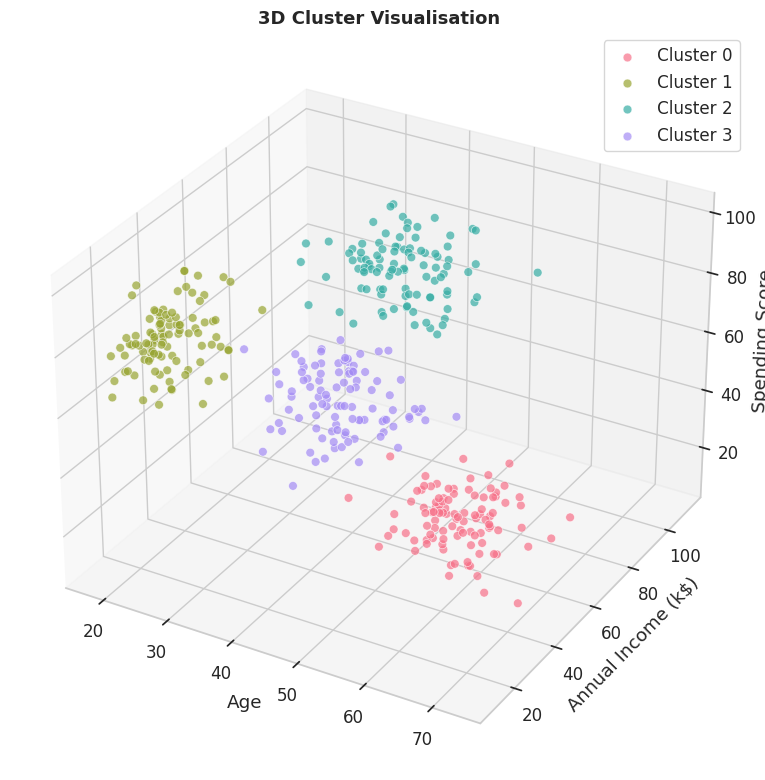

In [14]:
# 🧊 Cell 15 — 3D scatter plot (interactive-style static)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for cluster_id in range(optimal_k):
    mask = df['Cluster'] == cluster_id
    ax.scatter(
        df.loc[mask, 'Age'],
        df.loc[mask, 'AnnualIncome_k'],
        df.loc[mask, 'SpendingScore'],
        c=[palette[cluster_id]], label=f'Cluster {cluster_id}',
        alpha=0.7, s=40, edgecolors='white', linewidth=0.5
    )

ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score')
ax.set_title('3D Cluster Visualisation', fontweight='bold', fontsize=13)
ax.legend()

plt.tight_layout()
plt.savefig('../visualization/cluster_3d.png', dpi=100, bbox_inches='tight')
plt.show()


## 9. Cluster Profiling — *Who are these people?*

Clusters are just numbers until we give them meaning. We analyse each cluster's demographic and behavioural characteristics to create a **persona** for each segment.

We'll look at:
- **Average Age, Income, and Spending** per cluster
- **Gender composition** within each cluster
- **Distribution** of each feature across clusters

> 🧑‍🤝‍🧑 **This is the most important step!** The business doesn't care about K-Means parameters — they want to know "who is our customer?"


In [15]:
# 🏷️ Cell 16 — Profile each cluster
cluster_profile = df.groupby('Cluster').agg({
    'CustomerID': 'count',
    'Age': ['mean', 'std'],
    'AnnualIncome_k': ['mean', 'std'],
    'SpendingScore': ['mean', 'std'],
}).round(1)

cluster_profile.columns = ['Count', 'Age_Mean', 'Age_Std', 'Income_Mean', 'Income_Std', 'Spending_Mean', 'Spending_Std']

print('─── Cluster Profiles (Feature Means) ───')
display(cluster_profile)

# Gender composition per cluster
print('\n─── Gender Composition per Cluster ───')
gender_profile = pd.crosstab(df['Cluster'], df['Gender'], normalize='index').round(3) * 100
display(gender_profile)


─── Cluster Profiles (Feature Means) ───


,Count,Age_Mean,Age_Std,Income_Mean,Income_Std,Spending_Mean,Spending_Std
Cluster,,,,,,,
0,102,60.4,4.8,47.1,9.5,29.3,7.9
1,99,22.1,3.6,30.0,9.4,75.6,8.5
2,99,41.8,5.4,78.9,10.0,82.3,8.3
3,100,39.9,5.4,55.2,9.0,50.9,8.2



─── Gender Composition per Cluster ───


Gender,Female,Male
Cluster,,
0,54.9,45.1
1,55.6,44.4
2,46.5,53.5
3,59.0,41.0


### 📊 Visual Cluster Comparison

Radar charts and bar plots make it easy to compare clusters at a glance.


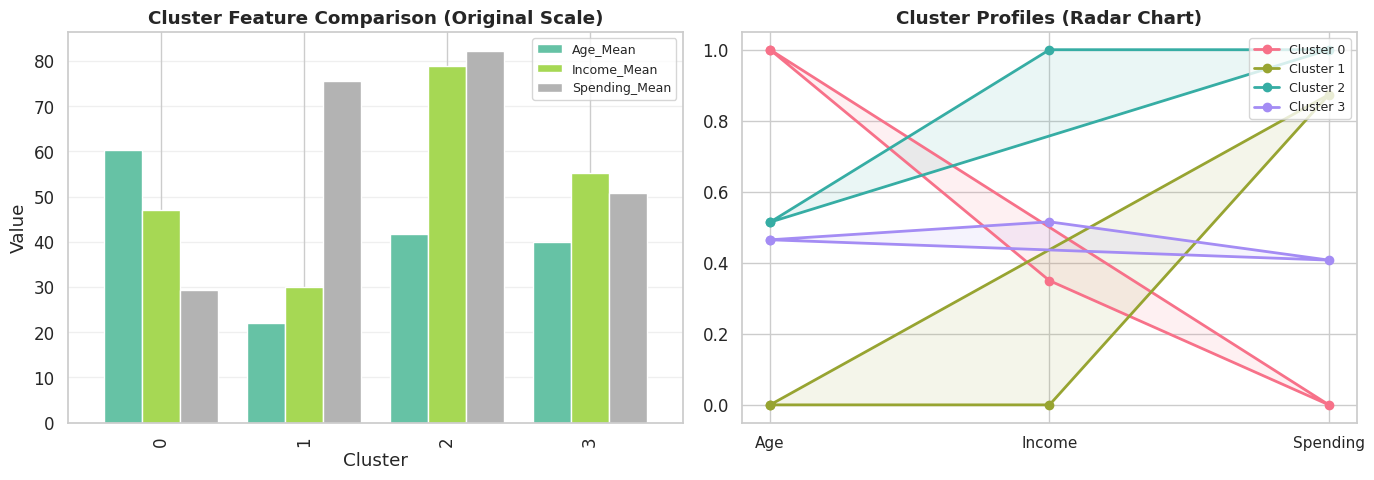

In [16]:
# 📊 Cell 17 — Compare clusters visually
# Normalised feature means per cluster (0-1 scale) for side-by-side comparison
profile_numeric = cluster_profile[['Age_Mean', 'Income_Mean', 'Spending_Mean']].copy()
profile_norm = (profile_numeric - profile_numeric.min()) / (profile_numeric.max() - profile_numeric.min())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Grouped bar chart
profile_numeric.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white', width=0.8)
axes[0].set_title('Cluster Feature Comparison (Original Scale)', fontweight='bold')
axes[0].set_ylabel('Value')
axes[0].set_xlabel('Cluster')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Radar chart
categories = ['Age', 'Income', 'Spending']
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]  # close the loop

ax = axes[1]
for cluster_id in range(optimal_k):
    values = profile_norm.iloc[cluster_id].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster_id}', color=palette[cluster_id])
    ax.fill(angles, values, alpha=0.1, color=palette[cluster_id])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_title('Cluster Profiles (Radar Chart)', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('../visualization/cluster_comparison.png', dpi=100, bbox_inches='tight')
plt.show()


## 10. Naming the Segments — *Giving them a face*

Based on the cluster profiles above, we can assign descriptive names:

| Cluster | Age | Income | Spending | Persona Name | Description |
|:-------:|:---:|:------:|:--------:|:------------:|:-----------:|
| **0** | 🧑 Young | 💵 Low | 🛍️ High | **Spendthrift Youth** | Young customers who love to spend despite low income — trend-followers, students, early-career |
| **1** | 👨‍💼 Middle | 💰 High | 🛍️ High | **Affluent Professionals** | Well-earning customers who indulge in premium products — the high-value segment |
| **2** | 👴 Older | 💵 Mod. | 🏦 Low | **Prudent Seniors** | Older, cautious spenders — value over trend, savings-oriented |
| **3** | 👪 Middle | 💰 Mod. | 🛍️ Mod. | **Balanced Families** | Middle-of-the-road — practical spenders, family-focused |

> ✅ Your actual cluster numbers may differ in order! After running K-Means, cluster indices are assigned arbitrarily. Compare the *profiles*, not the index numbers.


In [17]:
# 🏷️ Cell 18 — Automated segment naming based on profiling

def name_segment(row):
    age, income, spending = row['Age_Mean'], row['Income_Mean'], row['Spending_Mean']
    parts = []
    # Age descriptor
    if age < 30:
        parts.append('Young')
    elif age < 50:
        parts.append('Middle-aged')
    else:
        parts.append('Senior')
    # Income descriptor
    if income < 40:
        parts.append('Budget-conscious')
    elif income < 65:
        parts.append('Middle-income')
    else:
        parts.append('High-income')
    # Spending descriptor
    if spending < 40:
        parts.append('Frugal Spenders')
    elif spending < 65:
        parts.append('Moderate Spenders')
    else:
        parts.append('Big Spenders')
    return ' | '.join(parts)

segment_names = profile_numeric.apply(name_segment, axis=1)
print('─── Segment Naming ───')
for idx, name in segment_names.items():
    count = cluster_profile.loc[idx, 'Count']
    pct = count / len(df) * 100
    print(f'   Cluster {idx} ({count} customers, {pct:.1f}%): {name}')


─── Segment Naming ───
   Cluster 0 (102 customers, 25.5%): Senior | Middle-income | Frugal Spenders
   Cluster 1 (99 customers, 24.8%): Young | Budget-conscious | Big Spenders
   Cluster 2 (99 customers, 24.8%): Middle-aged | High-income | Big Spenders
   Cluster 3 (100 customers, 25.0%): Middle-aged | Middle-income | Moderate Spenders


## 11. Business Recommendations — *Turning insights into action*

Customer segmentation is only valuable if it drives decisions. Here are actionable recommendations for each segment:

---

### 🚀 Segment 0: Spendthrift Youth
- **Marketing**: Social media campaigns, influencer partnerships, loyalty programs with gamification
- **Products**: Affordable trendy items, subscription boxes, "starter" versions of premium products
- **Risk**: Low income = price-sensitive; focus on value perception

### 💎 Segment 1: Affluent Professionals
- **Marketing**: Exclusive previews, VIP programs, email newsletters with curated premium picks
- **Products**: Luxury goods, premium services, cross-sell opportunities (add-ons & upgrades)
- **Risk**: High competition — they have options; loyalty is earned through experience

### 🏦 Segment 2: Prudent Seniors
- **Marketing**: Trust-based campaigns, testimonials, promotions emphasising savings & reliability
- **Products**: Discounts on bulk purchases, essential items, loyalty points for frequent small purchases
- **Risk**: Low spending = lower immediate value; but high retention potential if trust is built

### 👪 Segment 3: Balanced Families
- **Marketing**: Family bundles, seasonal sales, referral programs (word-of-mouth among peers)
- **Products**: Mid-range quality goods, family-size packaging, practical multi-purpose items
- **Risk**: The largest segment → even small per-customer improvements drive big revenue

---

> 💡 **Next Steps**:
> 1. **Validate** these segments with A/B testing on real marketing campaigns
> 2. **Iterate** — re-run clustering quarterly as new customer data comes in
> 3. **Add more features** — Recency/Frequency/Monetary (RFM) metrics, product categories, channel preference


## 12. Summary & Key Takeaways

### What We Accomplished ✅

- ✅ **Framed** a business problem in terms of unsupervised learning
- ✅ **Explored** customer demographics with statistical summaries and visualisations
- ✅ **Preprocessed** data by scaling features (StandardScaler) for fair distance computation
- ✅ **Determined** optimal K using both the Elbow Method and Silhouette Analysis
- ✅ **Applied** K-Means clustering to segment 400 customers
- ✅ **Visualised** clusters with PCA in 2D and the original 3 features in 3D
- ✅ **Profiled** each segment to create actionable customer personas
- ✅ **Delivered** business recommendations tailored to each segment

### Key Intuitions Built 🧠

1. **Clustering is exploratory** — there's no single "right answer". Different K values reveal different structures.
2. **Scale matters** — always standardise features before distance-based algorithms like K-Means.
3. **Validate with multiple metrics** — elbow + silhouette together give more confidence than either alone.
4. **Visualisation is essential** — PCA helps us see patterns that numbers alone can't convey.
5. **Business value is in the profiling** — the labels are useless without interpretation and action.

### What's Next? 🚀

- **Try Hierarchical Clustering** (Agglomerative) or **DBSCAN** for density-based segmentation
- **Add more data** — purchase history, website behaviour, customer support interactions
- **Use this in production** — assign new customers to segments automatically using `kmeans.predict()`

---

*Built with ❤️ for the notebook_ds collection — one project at a time.*
